### Homework Week 1

In [3]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
data_1_1 = pd.read_csv("homework_1.1.csv")

Linear regression on 1.1csv

In [4]:
X = data_1_1[['X1', 'X2', 'X3']]
y = data_1_1['Y']

model = LinearRegression()
model.fit(X, y)

print(f"Coefficients (X1, X2, X3): {model.coef_}")
print(f"Intercept: {model.intercept_}")

Coefficients (X1, X2, X3): [1.00713766 1.96456859 2.97548854]
Intercept: 0.0026430033444732604


In [5]:
# Simple regression coefficients
print("Simple Regression Coefficients:")
coefs_simple = {}
for col in ['X1', 'X2', 'X3']:
    model_simple = LinearRegression()
    model_simple.fit(data_1_1[[col]], data_1_1['Y'])
    coefs_simple[col] = model_simple.coef_[0]
    print(f"{col}: {coefs_simple[col]}")

print("\nMultiple Regression Coefficients:")
coefs_multiple = {'X1': model.coef_[0], 'X2': model.coef_[1], 'X3': model.coef_[2]}
for col in ['X1', 'X2', 'X3']:
    print(f"{col}: {coefs_multiple[col]}")
    
print("\nDifferences (Absolute):")
diffs = {}
for col in ['X1', 'X2', 'X3']:
    diffs[col] = abs(coefs_multiple[col] - coefs_simple[col])
    print(f"{col}: {diffs[col]}")

max_diff_col = max(diffs, key=diffs.get)
print(f"\nGreatest difference is for {max_diff_col}: {diffs[max_diff_col]}")

Simple Regression Coefficients:
X1: 1.8417610991715148
X2: 4.083612579423011
X3: 3.0970412020437936

Multiple Regression Coefficients:
X1: 1.0071376550759568
X2: 1.9645685948713516
X3: 2.9754885351434233

Differences (Absolute):
X1: 0.834623444095558
X2: 2.1190439845516598
X3: 0.12155266690037037

Greatest difference is for X2: 2.1190439845516598


In [6]:
import statsmodels.api as sm

# Add a constant for the intercept
X_with_const = sm.add_constant(X)
model_sm = sm.OLS(y, X_with_const).fit()

# Print the t-statistics
print(model_sm.tvalues)

const      0.166181
X1        60.984011
X2        53.283212
X3       196.645240
dtype: float64


In [7]:
data_1_2 = pd.read_csv("homework_1.2.csv")

In [8]:
from sklearn.neighbors import NearestNeighbors

# Extract the Z variable for matching
Z_values = data_1_2[['Z']]

# NearestNeighbors
nn = NearestNeighbors(n_neighbors=2) 
nn.fit(Z_values)

# Find distances and indices of the nearestneighbors
distances, indices = nn.kneighbors(Z_values)

# Display some of the matches (ignoring the point matching itself)
print("Distances to nearest neighbor:\n", distances[:, 1][:10])
print("Indices of nearest neighbor:\n", indices[:, 1][:10])

Distances to nearest neighbor:
 [0.00393032 0.00113784 0.00208214 0.00393032 0.00899286 0.00597309
 0.00055526 0.02176085 0.0127967  0.01471635]
Indices of nearest neighbor:
 [ 3 93 73  0 29 25 41 19 70 65]


In [9]:
from sklearn.neighbors import NearestNeighbors

# Separate data based on X
data_x0 = data_1_2[data_1_2['X'] == 0]
data_x1 = data_1_2[data_1_2['X'] == 1]

# NearestNeighbors for radius matching
nn_radius = NearestNeighbors(radius=0.2)
nn_radius.fit(data_x0[['Z']])

# Find all matches in X=0 for each X=1 within distance 0.2
distances_radius, indices_radius = nn_radius.radius_neighbors(data_x1[['Z']])

# Collect the matched X=0 samples
matched_x0_list = []
for i, x1_idx in enumerate(data_x1.index):
    # indices_radius[i] contains the positional indices in data_x0
    match_indices_in_x0 = indices_radius[i]
    if len(match_indices_in_x0) > 0:
        # Get the actual DataFrame indices from data_x0
        actual_indices = data_x0.iloc[match_indices_in_x0].index
        
        for idx in actual_indices:
            matched_x0_list.append(data_x0.loc[idx])

import pandas as pd
# DataFrame containing all matched X=0 samples (duplicates included)
matched_x0_df = pd.DataFrame(matched_x0_list)

print(f"Total X=1 samples: {len(data_x1)}")
print(f"Total matched X=0 samples (including duplicates): {len(matched_x0_df)}")
print(f"Number of unique matched X=0 samples: {matched_x0_df.index.nunique()}")


Total X=1 samples: 48
Total matched X=0 samples (including duplicates): 737
Number of unique matched X=0 samples: 52


In [10]:
# Number of duplicate matches
total_matches = len(matched_x0_df)
unique_matches = matched_x0_df.index.nunique()
duplicates = total_matches - unique_matches

print(f"Total matched X=0 samples: {total_matches}")
print(f"Unique matched X=0 samples: {unique_matches}")
print(f"Number of duplicates (all but the first): {duplicates}")

Total matched X=0 samples: 737
Unique matched X=0 samples: 52
Number of duplicates (all but the first): 685


In [11]:
import numpy as np

effects = []

# Loop over each X=1 item and its neighbors
for i, x1_idx in enumerate(data_x1.index):
    match_indices_in_x0 = indices_radius[i]
    
    if len(match_indices_in_x0) > 0:
        # Get the DataFrame indices for the matched X=0 item(s)
        actual_indices = data_x0.iloc[match_indices_in_x0].index
        
        # Compute the mean Y for this neighbor group
        mean_y0 = data_x0.loc[actual_indices, 'Y'].mean()
        
        # Get the Y value for the current X=1 item
        y1 = data_x1.loc[x1_idx, 'Y']
        
        # Add the difference observed (Y1 - Y0) to our effects list
        effects.append(y1 - mean_y0)

# Calculate the overall average effect
average_effect = np.mean(effects)

print(f"Number of X=1 samples with at least one match: {len(effects)}")
print(f"The average treatment effect is: {average_effect}")

Number of X=1 samples with at least one match: 46
The average treatment effect is: 0.5688516534127853


### Homework Week 2

#### 2.1 regression for estimating fixed effect of each group

In [26]:
import pandas as pd
import statsmodels.formula.api as smf

# Read the data
df_2_1 = pd.read_csv('homework_2.1.csv')

# Melt the data into long format
df_long = pd.melt(df_2_1, id_vars=['time'], value_vars=['G1', 'G2', 'G3'], var_name='Group', value_name='Outcome')

# Fixed effects model
# OLS formula with a single time coefficient and dummy variables representing the group fixed effects
# using '- 1' removes the global intercept and gives an intercept (fixed effect) for each group
model_fixed_effects = smf.ols('Outcome ~ time + C(Group) - 1', data=df_long).fit()
print("Fixed Effects Model Summary:")
print(model_fixed_effects.summary())


print("\nIndividual regressions per group:")
for group in ['G1', 'G2', 'G3']:
    model = smf.ols(f'{group} ~ time', data=df_2_1).fit()
    print(f'Group {group}: Time Coefficient = {model.params["time"]:.5f}')

Fixed Effects Model Summary:
                            OLS Regression Results                            
Dep. Variable:                Outcome   R-squared:                       0.311
Model:                            OLS   Adj. R-squared:                  0.304
Method:                 Least Squares   F-statistic:                     44.55
Date:                Thu, 28 May 2026   Prob (F-statistic):           8.72e-24
Time:                        23:09:01   Log-Likelihood:                -216.89
No. Observations:                 300   AIC:                             441.8
Df Residuals:                     296   BIC:                             456.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
C(Group)[G1]     0.

In [13]:
# Extract and print the common linear coefficient (the coefficient for 'time')
common_time_coef = model_fixed_effects.params['time']
print(f"The common linear coefficient for 'time' across all groups is: {common_time_coef:.6f}")

The common linear coefficient for 'time' across all groups is: 0.009017


Bootstrap Mean Coefficient for X: 2.8197
95% Confidence Interval for X: [2.4819, 3.1531]


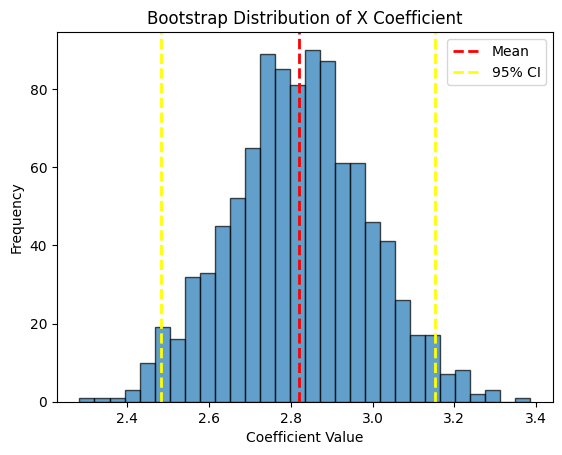

In [14]:
# Load the file 
df_2_2 = pd.read_csv('homework_2.2.csv')

# Set up parameters for the bootstrap simulation
n_iterations = 1000
bootstrap_coefs_X = []

# X is the treatment, Y is outcome, Z is a covariate
# Bootstrap the coefficient of X in the regression Y ~ X + Z
np.random.seed(42)
for i in range(n_iterations):
    # Sample with replacement
    df_sample = df_2_2.sample(frac=1, replace=True)
    
    # Fit regression model
    model = smf.ols('Y ~ X + Z', data=df_sample).fit()
    
    # Store the coefficient of X
    bootstrap_coefs_X.append(model.params['X'])

# Calculate the mean and 95% confidence interval
mean_coef = np.mean(bootstrap_coefs_X)
ci_lower = np.percentile(bootstrap_coefs_X, 2.5)
ci_upper = np.percentile(bootstrap_coefs_X, 97.5)

print(f"Bootstrap Mean Coefficient for X: {mean_coef:.4f}")
print(f"95% Confidence Interval for X: [{ci_lower:.4f}, {ci_upper:.4f}]")

# plot the distribution of bootstrapped coefficients
plt.hist(bootstrap_coefs_X, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(mean_coef, color='red', linestyle='dashed', linewidth=2, label='Mean')
plt.axvline(ci_lower, color='yellow', linestyle='dashed', linewidth=2, label='95% CI')
plt.axvline(ci_upper, color='yellow', linestyle='dashed', linewidth=2)
plt.title('Bootstrap Distribution of X Coefficient')
plt.xlabel('Coefficient Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()


In [15]:
# Calculate difference in means
mean_treated = df_2_2[df_2_2['X'] == 1]['Y'].mean()
mean_untreated = df_2_2[df_2_2['X'] == 0]['Y'].mean()
simple_effect = mean_treated - mean_untreated

print(f"Mean Outcome (Treated): {mean_treated:.4f}")
print(f"Mean Outcome (Untreated): {mean_untreated:.4f}")
print(f"Simple Treatment Effect (Treated - Untreated): {simple_effect:.4f}")

Mean Outcome (Treated): 7.8428
Mean Outcome (Untreated): 4.9220
Simple Treatment Effect (Treated - Untreated): 2.9207


In [16]:
# Bootstrap sampling to find the variance 
np.random.seed(42)
n_iterations = 1000
bootstrap_simple_effects = []

for i in range(n_iterations):
    # Sample with replacement
    df_sample = df_2_2.sample(frac=1, replace=True)
    
    # Calculate simple difference in means
    mean_treated_sample = df_sample[df_sample['X'] == 1]['Y'].mean()
    mean_untreated_sample = df_sample[df_sample['X'] == 0]['Y'].mean()
    
    bootstrap_simple_effects.append(mean_treated_sample - mean_untreated_sample)

# Calculate the variance
variance_simple_effect = np.var(bootstrap_simple_effects)

print(f"Variance of the simple effect (using bootstrap): {variance_simple_effect:.6f}")

Variance of the simple effect (using bootstrap): 0.031202


In [17]:
import scipy.stats as stats

# Skewness of the effect measured using linear regression (Y ~ X)
np.random.seed(42)
bootstrap_coefs_simple_reg = []

for i in range(n_iterations):
    df_sample = df_2_2.sample(frac=1, replace=True)
    # Linear regression with intercept to measure the simple effect: Y ~ X
    model = smf.ols('Y ~ X', data=df_sample).fit()
    bootstrap_coefs_simple_reg.append(model.params['X'])

skew_simple_reg = stats.skew(bootstrap_coefs_simple_reg)
print(f"Skewness of the effect measured using simple linear regression (Y ~ X): {skew_simple_reg:.6f}")

# Skewness of the effect measured using multiple linear regression (Y ~ X + Z) 
skew_multiple_reg = stats.skew(bootstrap_coefs_X)
print(f"Skewness of the effect measured using multiple linear regression (Y ~ X + Z): {skew_multiple_reg:.6f}")

# Skewness of the simple difference in means
skew_simple_diff = stats.skew(bootstrap_simple_effects)
print(f"Skewness of the effect measured using simple difference in means: {skew_simple_diff:.6f}")

Skewness of the effect measured using simple linear regression (Y ~ X): 0.087234
Skewness of the effect measured using multiple linear regression (Y ~ X + Z): 0.026992
Skewness of the effect measured using simple difference in means: 0.087234


### Homework Week 3 

In [21]:
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# Load the dataset
df_3_1 = pd.read_csv('homework_3.1.csv')

# Assume the event occurs halfway through the time series (time = 50)
event_time = 50
df_3_1['post_event'] = (df_3_1['time'] >= event_time).astype(int)
df_3_1['time_centered'] = df_3_1['time'] - event_time

print("Testing for Discontinuity at the Event (time = 50)")
for var in ['value1', 'value2', 'value3']:
    print(f"\n{'='*40}")
    print(f"Variable: {var}")
    print(f"{'='*40}")
    
    # Model 1: Discontinuity in value (intercept) only
    mod1 = smf.ols(f"{var} ~ time_centered + post_event", data=df_3_1).fit()
    print("Model 1 (Discontinuity in Value Only):")
    p_val1 = mod1.pvalues['post_event']
    print(f"  Post-Event Shift: {mod1.params['post_event']:.4f} (p-value: {p_val1:.4f})")
    
    # Model 2: Discontinuity in both value and derivative (slope)
    mod2 = smf.ols(f"{var} ~ time_centered * post_event", data=df_3_1).fit()
    print("\nModel 2 (Discontinuity in Value and Slope):")
    p_val2_intercept = mod2.pvalues['post_event']
    p_val2_slope = mod2.pvalues['time_centered:post_event']
    print(f"  Post-Event Value Shift (Intercept): {mod2.params['post_event']:.4f} (p-value: {p_val2_intercept:.4f})")
    print(f"  Post-Event Slope Shift (Derivative): {mod2.params['time_centered:post_event']:.4f} (p-value: {p_val2_slope:.4f})")


Testing for Discontinuity at the Event (time = 50)

Variable: value1
Model 1 (Discontinuity in Value Only):
  Post-Event Shift: 0.8508 (p-value: 0.0856)

Model 2 (Discontinuity in Value and Slope):
  Post-Event Value Shift (Intercept): 0.9035 (p-value: 0.0202)
  Post-Event Slope Shift (Derivative): 0.1053 (p-value: 0.0000)

Variable: value2
Model 1 (Discontinuity in Value Only):
  Post-Event Shift: 0.6827 (p-value: 0.1131)

Model 2 (Discontinuity in Value and Slope):
  Post-Event Value Shift (Intercept): 0.7012 (p-value: 0.0946)
  Post-Event Slope Shift (Derivative): 0.0369 (p-value: 0.0118)

Variable: value3
Model 1 (Discontinuity in Value Only):
  Post-Event Shift: 1.7673 (p-value: 0.0000)

Model 2 (Discontinuity in Value and Slope):
  Post-Event Value Shift (Intercept): 1.7926 (p-value: 0.0000)
  Post-Event Slope Shift (Derivative): 0.0507 (p-value: 0.0002)


C:\Users\santo\AppData\Local\Temp\ipykernel_12236\4104999714.py:10: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_3_1['post_event'] = (df_3_1['time'] >= event_time).astype(int)
C:\Users\santo\AppData\Local\Temp\ipykernel_12236\4104999714.

In [24]:
import pandas as pd
import statsmodels.formula.api as smf

df_3_2_a = pd.read_csv('homework_3.2.a.csv')
df_3_2_b = pd.read_csv('homework_3.2.b.csv')

print("=== Difference-in-Differences setup for dataset 3.2.a ===")
# Model for 3.2.a: outcome1 ~ group1 + time1 + group1:time1
# group1 acts as the Treatment dummy, time1 acts as the Post dummy
did_model_a = smf.ols('outcome1 ~ group1 * time1', data=df_3_2_a).fit()
print(did_model_a.summary().tables[1])
print("\nDiD Estimator for 3.2.a (group1:time1 interaction):", round(did_model_a.params['group1:time1'], 4))

print("\n\n=== Difference-in-Differences setup for dataset 3.2.b ===")
# Model for 3.2.b: outcome2 ~ group2 + time2 + group2:time2
# group2 acts as the Treatment dummy, time2 acts as the Post dummy
did_model_b = smf.ols('outcome2 ~ group2 * time2', data=df_3_2_b).fit()
print(did_model_b.summary().tables[1])
print("\nDiD Estimator for 3.2.b (group2:time2 interaction):", round(did_model_b.params['group2:time2'], 4))


=== Difference-in-Differences setup for dataset 3.2.a ===
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.0258      0.031     -0.829      0.408      -0.087       0.035
group1           1.9863      0.044     44.928      0.000       1.900       2.073
time1            1.4272      0.044     32.315      0.000       1.341       1.514
group1:time1     0.6858      0.063     10.970      0.000       0.563       0.809

DiD Estimator for 3.2.a (group1:time1 interaction): 0.6858


=== Difference-in-Differences setup for dataset 3.2.b ===
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.1021      0.073      1.392      0.164      -0.042       0.246
group2           1.8477      0.104     17.770      0.000       1.644       2.052
time2       

### Differences-in-Differences Scenario 2: Remote Work Policy Impact
**The Story:**
A tech company with two major offices (Office A and Office B) wants to evaluate whether allowing remote work affects employee productivity. Historically, both offices have had similar seasonal trends in productivity.
Starting in Week 7, the company introduces a "Flexible Remote Work" policy exclusively for **Office A** (the treatment group). **Office B** continues to mandate strict in-office attendance (the control group). 

The outcome metric we're tracking is the average number of "Tasks Completed" per employee each week over a 12-week period. By comparing the pre-policy (Weeks 1-6) and post-policy (Weeks 7-12) productivity between the two offices, we can test the causal impact of remote work on productivity using Differences-in-Differences.

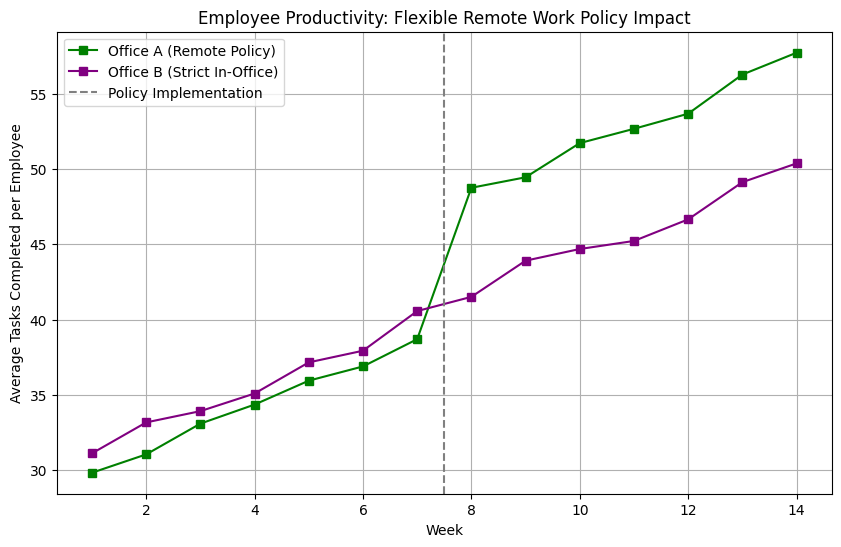

DiD Model Summary: Remote Work Policy
------------------------------------------------------------
Treatment Effect on Tasks Completed: 8.267 tasks/week
p-value: 0.0000
------------------------------------------------------------
                            OLS Regression Results                            
Dep. Variable:        Tasks_Completed   R-squared:                       0.537
Model:                            OLS   Adj. R-squared:                  0.536
Method:                 Least Squares   F-statistic:                     539.4
Date:                Fri, 29 May 2026   Prob (F-statistic):          9.88e-233
Time:                        18:41:46   Log-Likelihood:                -4734.8
No. Observations:                1400   AIC:                             9478.
Df Residuals:                    1396   BIC:                             9499.
Df Model:                           3                                         
Covariance Type:            nonrobust                      

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

np.random.seed(101)

# Synthetic data generation
n_employees = 100
weeks = 14
policy_week = 8

data = []
for emp in range(n_employees):
    # Office A is treated, Office B is control
    is_treated = 1 if emp >= (n_employees / 2) else 0
    
    # Base productivity varies slightly by employee
    base_tasks = np.random.normal(30, 5)
    
    for week in range(1, weeks + 1):
        is_post = 1 if week >= policy_week else 0
        
        # Treatment effect: WFH policy increases productivity by 8 tasks/week
        treatment_effect = 8 * is_treated * is_post
        
        # Shared time trend: company generally becomes busier as the quarter progresses
        time_trend = 1.5 * week
        
        # Initial group difference: Office A starts slightly lower baseline (-3 tasks)
        group_diff = -3 * is_treated
        
        # Random weekly fluctuations
        noise = np.random.normal(0, 3)
        
        tasks_completed = base_tasks + group_diff + time_trend + treatment_effect + noise
        
        data.append({
            'Employee': emp,
            'Week': week,
            'Office_A_Treated': is_treated,
            'Post_Policy': is_post,
            'Tasks_Completed': tasks_completed
        })

df_remote = pd.DataFrame(data)

# Aggregate for plotting
summary_remote = df_remote.groupby(['Week', 'Office_A_Treated'])['Tasks_Completed'].mean().unstack()

plt.figure(figsize=(10, 6))
plt.plot(summary_remote.index, summary_remote[1], marker='s', label='Office A (Remote Policy)', color='green')
plt.plot(summary_remote.index, summary_remote[0], marker='s', label='Office B (Strict In-Office)', color='purple')
plt.axvline(x=policy_week - 0.5, color='gray', linestyle='--', label='Policy Implementation')
plt.title('Employee Productivity: Flexible Remote Work Policy Impact')
plt.xlabel('Week')
plt.ylabel('Average Tasks Completed per Employee')
plt.legend()
plt.grid(True)
plt.show()

# Difference-in-Differences Regression
# Formula: Outcome ~ Treatment + Post + (Treatment * Post)
did_model_remote = smf.ols('Tasks_Completed ~ Office_A_Treated * Post_Policy', data=df_remote).fit()

print("DiD Model Summary: Remote Work Policy")
print("-" * 60)
# The interaction coefficient is the causal estimator
print(f"Treatment Effect on Tasks Completed: {did_model_remote.params['Office_A_Treated:Post_Policy']:.3f} tasks/week")
print(f"p-value: {did_model_remote.pvalues['Office_A_Treated:Post_Policy']:.4f}")
print("-" * 60)
print(did_model_remote.summary())